In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
def fetch_creditcard(X_y_split: bool = False
                     ) -> pd.DataFrame | tuple[pd.DataFrame, pd.Series]:
    response = requests.get("http://pipeline:8000/dataset/creditcard-churn", params={"X_y_split": X_y_split})
    payload = response.json()
    
    if X_y_split:
        X = pd.DataFrame(payload["x"], index=payload["index"])
        y = pd.Series(payload["y"], index=payload["index"])
        return X, y
    
    df = pd.DataFrame(payload["data"], index=payload["index"])
    
    return df

In [3]:
# 데이터 로드
bank_df = fetch_creditcard()
bank_df = bank_df.drop("creditcard_churn_id", axis=1)
print(bank_df.head())

   churn  age  gender  dependents  education_id  marital_id  income_id  \
0      1   35       0           4             7           2          1   
1      1   47       1           0             1           4          2   
2      1   26       1           1             4           4          3   
3      1   36       0           1             5           3          5   
4      1   64       1           2             7           3          6   

   card_type_id  relationship_months  product_count  inactive_months  \
0             2                   23              6                5   
1             4                   21              6                0   
2             3                   45              4                2   
3             1                   46              2                4   
4             1                   12              6                1   

   contact_count  credit_limit  revolving_balance  available_credit  \
0              3       8882.21             385.10  

In [4]:
features = [k for k in bank_df.columns if k != "income_id"]
# features = ["revolving_balance", "transaction_count", "count_change", "contact_count"]
# features = ["credit_limit", "available_credit", "utilization_ratio"]
features_df = bank_df[features]
income_df = bank_df['income_id']

print(features_df.describe())
print(income_df.value_counts())

              churn           age        gender    dependents  education_id  \
count  10227.000000  10227.000000  10227.000000  10227.000000  10227.000000   
mean       0.162902     46.294710      0.471008      2.342916      3.654737   
std        0.369294      8.062244      0.499183      1.300694      1.918032   
min        0.000000     25.000000      0.000000      0.000000      1.000000   
25%        0.000000     41.000000      0.000000      1.000000      2.000000   
50%        0.000000     46.000000      0.000000      2.000000      4.000000   
75%        0.000000     52.000000      1.000000      3.000000      4.000000   
max        1.000000     73.000000      1.000000      5.000000      7.000000   

         marital_id  card_type_id  relationship_months  product_count  \
count  10227.000000  10227.000000         10227.000000   10227.000000   
mean       1.837880      1.103647            35.922753       3.809622   
std        0.859548      0.409181             8.143917       1.557313

In [5]:
features_known_df = features_df[income_df != 6]
features_unknown_df = features_df[income_df == 6]
income_known_df = income_df[income_df != 6]
income_unknown_df = income_df[income_df == 6]

print(features_known_df.describe())
print(income_known_df.value_counts())

             churn          age       gender   dependents  education_id  \
count  9104.000000  9104.000000  9104.000000  9104.000000   9104.000000   
mean      0.162017    46.301076     0.522847     2.350945      3.664982   
std       0.368486     7.980682     0.499505     1.296940      1.917392   
min       0.000000    25.000000     0.000000     0.000000      1.000000   
25%       0.000000    41.000000     0.000000     1.000000      2.000000   
50%       0.000000    46.000000     1.000000     2.000000      4.000000   
75%       0.000000    52.000000     1.000000     3.000000      4.000000   
max       1.000000    73.000000     1.000000     5.000000      7.000000   

        marital_id  card_type_id  relationship_months  product_count  \
count  9104.000000   9104.000000          9104.000000    9104.000000   
mean      1.838203      1.104130            35.946068       3.809644   
std       0.858344      0.406647             8.083102       1.558945   
min       1.000000      1.000000    

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_known_df_scaled = scaler.fit_transform(features_known_df)
features_unknown_df_scaled = scaler.transform(features_unknown_df)

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
features_known_df_lda = lda.fit_transform(features_known_df_scaled, income_known_df)
features_unknown_df_lda = lda.transform(features_unknown_df_scaled)

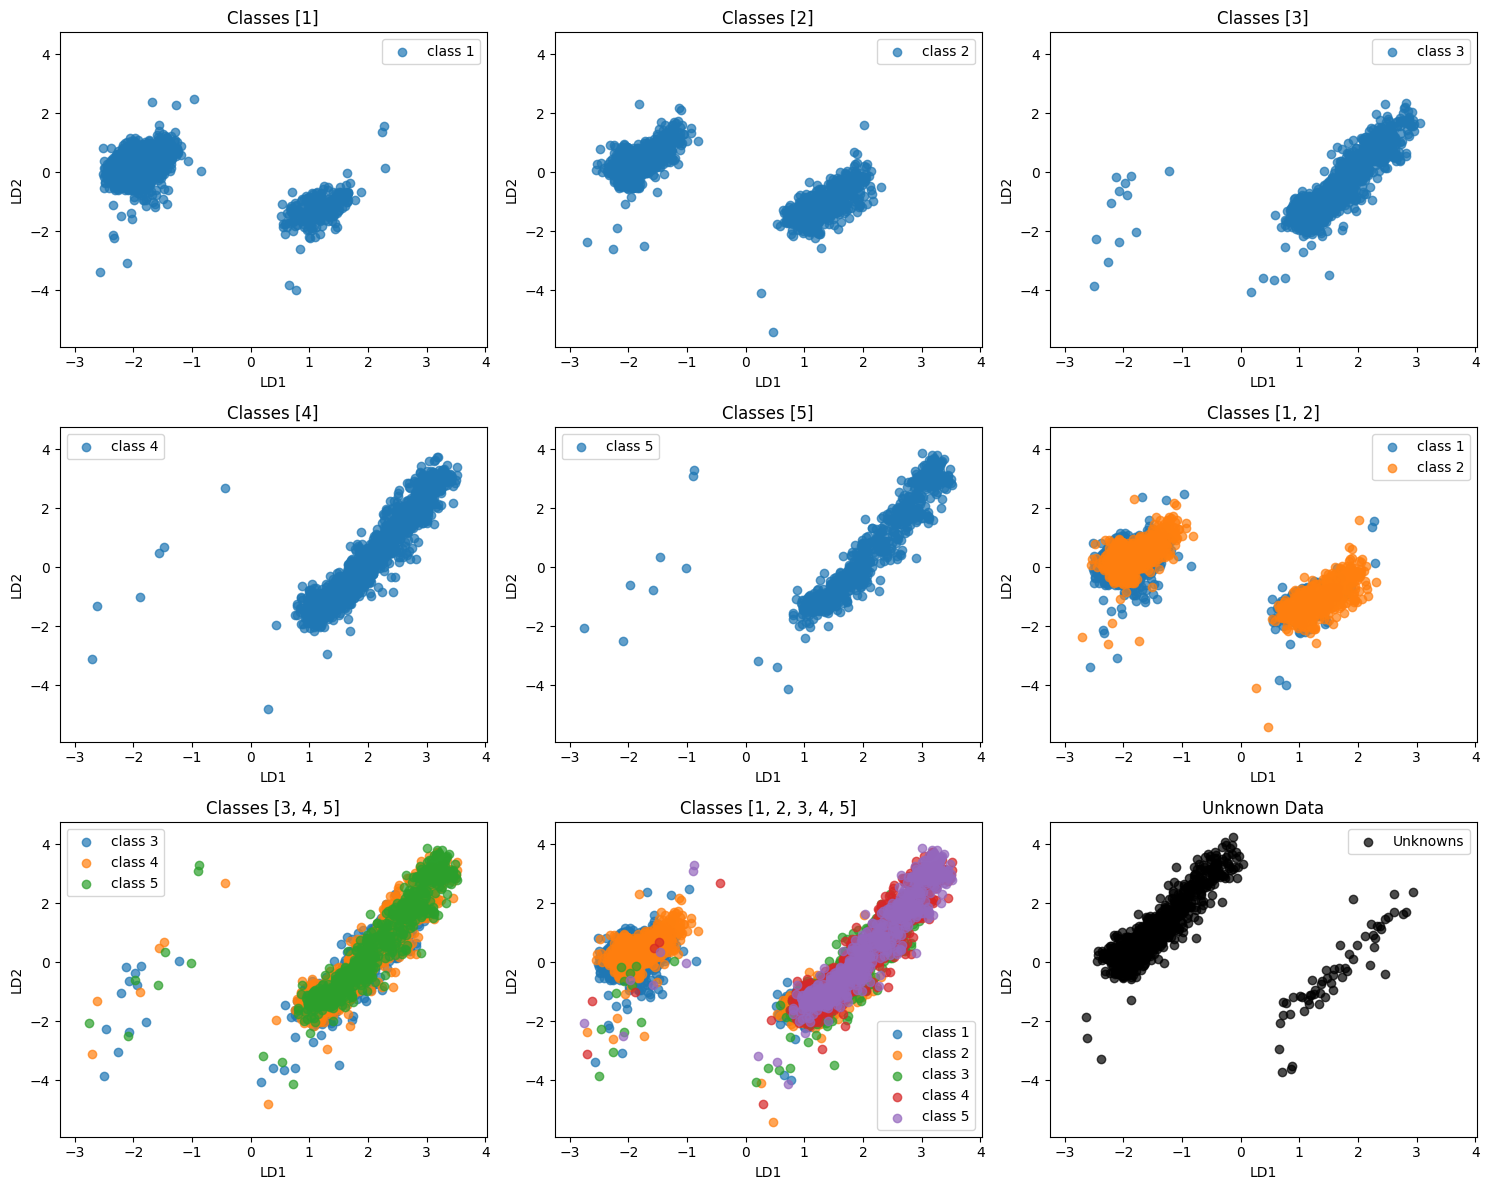

In [8]:
import matplotlib.pyplot as plt
import numpy as np

groups = [
    [1],
    [2],
    [3],
    [4],
    [5],
    [1,2],
    [3,4,5],
    [1,2,3,4,5]
]

# 전체 데이터 범위 계산
all_x = np.concatenate([features_known_df_lda[:,0], features_unknown_df_lda[:,0]])
all_y = np.concatenate([features_known_df_lda[:,1], features_unknown_df_lda[:,1]])

margin = 0.5
xlim = (all_x.min()-margin, all_x.max()+margin)
ylim = (all_y.min()-margin, all_y.max()+margin)

fig, axes = plt.subplots(3,3, figsize=(15,12))
axes = axes.flatten()

# 클래스 데이터 subplot
for ax, group in zip(axes[:8], groups):

    for c in group:
        ax.scatter(
            features_known_df_lda[income_known_df==c,0],
            features_known_df_lda[income_known_df==c,1],
            label=f"class {c}",
            alpha=0.7
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f"Classes {group}")
    ax.set_xlabel("LD1")
    ax.set_ylabel("LD2")
    ax.legend()

# Unknown subplot
ax = axes[8]
ax.scatter(
    features_unknown_df_lda[:,0],
    features_unknown_df_lda[:,1],
    label="Unknowns",
    color="black",
    alpha=0.7
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("Unknown Data")
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

y_data = income_known_df
# y_data = np.where(income_known_df <= 2, 0, 1)

train_X, test_X, train_y, test_y = train_test_split(
    features_known_df_scaled,
    y_data,
    stratify=y_data,
    random_state=42,
    test_size=0.2
)

In [10]:
def print_split_report(X_train, X_test, y_train, y_test):
    # [📊 요약 출력 - 팀 공통 규격]
    print(f"\n{'Train / Test Split Summary':^50}")
    print("="*50)
    print(f"X_train shape : {X_train.shape}")
    print(f"X_test  shape : {X_test.shape}")
    print("-"*50)
    print(f"y_train shape : {y_train.shape}")
    print(f"y_test  shape : {y_test.shape}")
    print("-"*50)
    print("Target Distribution (Train)")
    print(y_train.value_counts().to_string())
    print("-"*50)
    print("Target Distribution (Test)")
    print(y_test.value_counts().to_string())
    print("-"*50)
    print("Train Ratio")
    print(y_train.value_counts(normalize=True).to_string())
    print("-"*50)
    print("Test Ratio")
    print(y_test.value_counts(normalize=True).to_string())
    print("="*50)

print_split_report(pd.DataFrame(train_X), pd.DataFrame(test_X), pd.DataFrame(train_y), pd.DataFrame(test_y))


            Train / Test Split Summary            
X_train shape : (7283, 19)
X_test  shape : (1821, 19)
--------------------------------------------------
y_train shape : (7283, 1)
y_test  shape : (1821, 1)
--------------------------------------------------
Target Distribution (Train)
income_id
1            2865
2            1446
4            1237
3            1141
5             594
--------------------------------------------------
Target Distribution (Test)
income_id
1            717
2            361
4            309
3            285
5            149
--------------------------------------------------
Train Ratio
income_id
1            0.393382
2            0.198545
4            0.169848
3            0.156666
5            0.081560
--------------------------------------------------
Test Ratio
income_id
1            0.393740
2            0.198243
4            0.169687
3            0.156507
5            0.081823


In [11]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.multiclass import type_of_target


def print_report(y_true, y_pred, y_proba, classes=None, average="macro", dataset_name="Dataset"):
    target_type = type_of_target(y_true)

    result = {
        "dataset": dataset_name,
        "target_type": target_type,
        "accuracy": accuracy_score(y_true, y_pred),
    }

    # y_proba shape 보정
    y_proba = np.asarray(y_proba)

    if target_type == "binary":
        result["recall"] = recall_score(y_true, y_pred)
        result["f1"] = f1_score(y_true, y_pred)

        # (n_samples, 2) 이면 positive class 확률만 사용
        if y_proba.ndim == 2 and y_proba.shape[1] == 2:
            y_score = y_proba[:, 1]
        # 이미 (n_samples,) 형태면 그대로 사용
        elif y_proba.ndim == 1:
            y_score = y_proba
        else:
            print(f"Binary Classification Shape Error: y_proba.shape = {y_proba.shape}")
            return

        result["roc_auc"] = roc_auc_score(y_true, y_score)
        result["pr_auc"] = average_precision_score(y_true, y_score)
        result["precision_score"] = precision_score(y_true, y_pred)

    elif target_type == "multiclass":
        result["recall"] = recall_score(y_true, y_pred, average=average)
        result["f1"] = f1_score(y_true, y_pred, average=average)

        if y_proba.ndim != 2:
            raise ValueError(f"Multiclass classification에서는 y_proba가 2차원이어야 합니다: {y_proba.shape}")

        result["roc_auc"] = roc_auc_score(
            y_true,
            y_proba,
            multi_class="ovr",
            average=average
        )

        if classes is None:
            classes = np.unique(y_true)

        y_true_bin = label_binarize(y_true, classes=classes)
        result["pr_auc"] = average_precision_score(
            y_true_bin,
            y_proba,
            average=average
        )
        
        result["precision_score"] = precision_score(y_true, y_pred, average=average)

    else:
        raise ValueError(f"지원하지 않는 target type입니다: {target_type}")

    print("=" * 20, f"{result["dataset"]}", "="*20)
    print(f"{"target type":>20}: {result["target_type"]}")
    for k in [key for key in result if key not in ["dataset", "target_type"]]:
        print(f"{k:>20}: {result[k]:.6f}")


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(train_X, train_y)

train_pred = lr.predict(train_X)
test_pred = lr.predict(test_X)

train_proba = lr.predict_proba(train_X)
test_proba = lr.predict_proba(test_X)

print_report(
    y_true=train_y,
    y_pred=train_pred,
    y_proba=train_proba,
    classes=lr.classes_,
    dataset_name="Train"
)

print_report(
    y_true=test_y,
    y_pred=test_pred,
    y_proba=test_proba,
    classes=lr.classes_,
    dataset_name="Test"
)

==================== Train ====================
         target type: multiclass
            accuracy: 0.570095
              recall: 0.435595
                  f1: 0.402960
             roc_auc: 0.822349
              pr_auc: 0.461531
     precision_score: 0.475841
==================== Test ====================
         target type: multiclass
            accuracy: 0.551895
              recall: 0.415238
                  f1: 0.383478
             roc_auc: 0.807715
              pr_auc: 0.436092
     precision_score: 0.453150


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42, max_depth=3)
rf_clf.fit(train_X, train_y)

train_pred = rf_clf.predict(train_X)
test_pred = rf_clf.predict(test_X)

train_prob = rf_clf.predict_proba(train_X)
test_prob = rf_clf.predict_proba(test_X)

print_report(
    y_true=train_y,
    y_pred=train_pred,
    y_proba=train_proba,
    classes=rf_clf.classes_,
    dataset_name="Train"
)

print_report(
    y_true=test_y,
    y_pred=test_pred,
    y_proba=test_proba,
    classes=rf_clf.classes_,
    dataset_name="Test"
)


==================== Train ====================
         target type: multiclass
            accuracy: 0.536043
              recall: 0.377910
                  f1: 0.319694
             roc_auc: 0.822349
              pr_auc: 0.461531
     precision_score: 0.454747
==================== Test ====================
         target type: multiclass
            accuracy: 0.535420
              recall: 0.376114
                  f1: 0.319808
             roc_auc: 0.807715
              pr_auc: 0.436092
     precision_score: 0.455818


/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
def print_valcnt(arr):
    values, counts = np.unique(arr, return_counts=True)

    print("values :", " ".join(f"{v:>5}" for v in values))
    print("counts :", " ".join(f"{c:>5}" for c in counts))

In [15]:
lr_predicted = lr.predict(features_unknown_df_scaled)
rf_clf_predicted = rf_clf.predict(features_unknown_df_scaled)

print("===== 각 모델 예측된 클래스 수 =====")
print("LinearRegressor")
print_valcnt(lr_predicted)
print()
print("RandomForestClassifier")
print_valcnt(rf_clf_predicted)

print()

print("===== 서로 다르게 예측된 데이터들 ======")
print(f"다르게 예측된 데이터 수: {(lr_predicted != rf_clf_predicted).sum()}/{len(lr_predicted)}")
print(lr_predicted[(lr_predicted != rf_clf_predicted)])
print(rf_clf_predicted[(lr_predicted != rf_clf_predicted)])

===== 각 모델 예측된 클래스 수 =====
LinearRegressor
values :     1     2     3     4     5
counts :   797   269    19    25    13

RandomForestClassifier
values :     1     2     3     4
counts :   957   127     7    32

===== 서로 다르게 예측된 데이터들 ======
다르게 예측된 데이터 수: 179/1123
[2 3 2 3 2 2 2 2 2 3 2 2 2 2 2 2 2 2 2 2 2 4 2 2 2 5 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 3 2 2 2 2 2 5 2 2 2 2 3 5 2 2 2 2 5 2 3 2 2 2 2 2 3 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 3 2 2 2 2 2 2 2 5 2 2 2 2 2 5 2 2 5 2 5 2 2 2 2 2 2 2
 3 2 2 2 5 2 2 2 2 4 2 2 2 2 2 2 2 3 2 2 2 2 2 2 2 2 2 5 2 2 2 2 2 2 2 2 3
 2 2 2 2 5 5 3 5 2 2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
[1 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 4 1 1 1 1 1 2 1 1 1 1 1 4 1 1 1 1 2 1 1 1 1 1 1 1 4 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 2 1 2 1 1 1 1 1 1 1
 4 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 2 4 4 1 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
